# Assignment 4: Regularization

In [40]:
import urllib.request
import os

os.makedirs('./data', exist_ok=True)

base_url = 'https://raw.githubusercontent.com/ds4e/undergrad_ml_assignments/main/data/'

files = ['cars_hw.csv', 'heart_failure_clinical_records_dataset.csv']

for f in files:
    urllib.request.urlretrieve(base_url + f, f'./data/{f}')
    print(f'Downloaded {f}')

Downloaded cars_hw.csv
Downloaded heart_failure_clinical_records_dataset.csv


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?


1. Large coefficients can overfit to noise in the training data. Adding a penalty on coefficient size forces the model to keep weights small unless they're truly earning their place, which helps generalization.

2. A higher α shrinks coefficients more, adding bias but reducing variance. A lower α behaves more like OLS, low bias but higher variance. Tuning α helps navigate that trade-off.

3. Both penlize large coefficients, but Ridge uses squared values (L2) and LASSO uses absolute values (L1). The difference is that LASSO can shrink coefficients all the way to zero, doing automatic feature selection, while Ridge just makes them small.

4. z-score normalize so the penalty treats all feature equally. Without scaling, features with larger units would have smaller coefficients and get penalized less, not because they matter less, but just due to scale.

5. Through cross-validation, try a grid of α values and pick the one with the lowest CV MSE. `LassoCV` handles this automatically.

6. No, CV MSE should measure prediction error on held-out data, which is just squared error. The penalty is only for fiting, including it would distort comparisons across different α values.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [42]:
cars = pd.read_csv('./data/cars_hw.csv')
cars['Age'] = 2024 - cars['Make_Year']

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(cars[['Mileage_Run', 'Age']])
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)
y = cars['Price']

In [43]:
lr = LinearRegression()
lr.fit(X_scaled, y)

coef_df = pd.DataFrame({'feature': feature_names, 'coef': lr.coef_})
print(coef_df)

             feature          coef
0                  1  0.000000e+00
1        Mileage_Run  6.686165e+05
2                Age -1.841941e+05
3      Mileage_Run^2 -1.494679e+05
4    Mileage_Run Age -1.251592e+06
5              Age^2  2.156399e+05
6      Mileage_Run^3 -6.514490e+04
7  Mileage_Run^2 Age  2.833392e+05
8  Mileage_Run Age^2  5.280829e+05
9              Age^3 -1.389370e+05


In [44]:

alphas = np.logspace(1,3,20)
lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X_scaled, y)
print('optimal alpha:', lasso.alpha_)

optimal alpha: 483.2930238571752


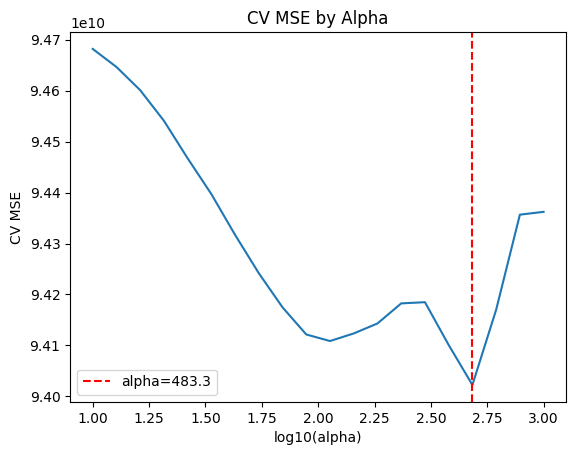

In [45]:
mean_mse = np.mean(lasso.mse_path_, axis=1)

plt.plot(np.log10(lasso.alphas_), mean_mse)
plt.axvline(np.log10(lasso.alpha_), color='red', linestyle='--', label=f'alpha={lasso.alpha_:.1f}')
plt.xlabel('log10(alpha)')
plt.ylabel('CV MSE')
plt.title('CV MSE by Alpha')
plt.legend()
plt.show()

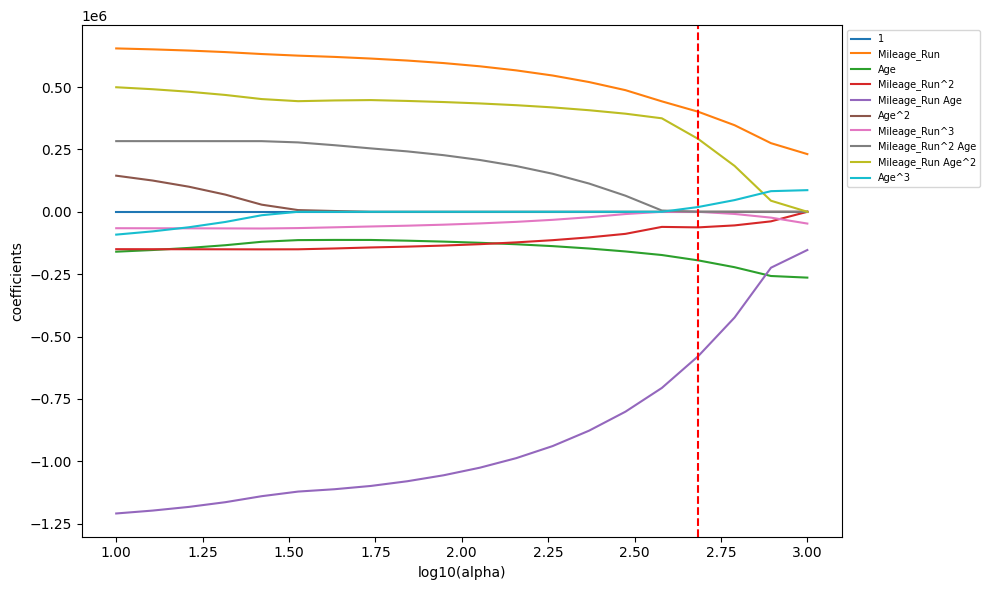

In [46]:

coefs = []
for a in alphas:
    m = Lasso(alpha=a, max_iter=100000)
    m.fit(X_scaled, y)
    coefs.append(m.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10,6))
for i in range(coefs.shape[1]):
    plt.plot(np.log10(alphas), coefs[:,i], label=feature_names[i])

plt.axvline(np.log10(lasso.alpha_), color='red', linestyle='--')
plt.xlabel('log10(alpha)')
plt.ylabel('coefficients')
plt.legend(fontsize=7, bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

In [47]:
lasso_coefs = pd.DataFrame({'feature': feature_names, 'coef': lasso.coef_})
selected = lasso_coefs[lasso_coefs['coef'] != 0]
prop_zero = (lasso_coefs['coef']==0).mean()

print(selected)
print('proportion zero:', round(prop_zero, 2))

             feature           coef
1        Mileage_Run  401025.259657
2                Age -194803.116695
3      Mileage_Run^2  -62539.290093
4    Mileage_Run Age -578788.661090
8  Mileage_Run Age^2  292015.025679
9              Age^3   19133.908573
proportion zero: 0.4


In [48]:
comparison = pd.DataFrame({'feature': feature_names, 'OLS': lr.coef_, 'LASSO': lasso.coef_})
comparison['mag_increased'] = abs(comparison['LASSO']) > abs(comparison['OLS'])
comparison['sign_changed'] = np.sign(comparison['OLS']) != np.sign(comparison['LASSO'])

print(comparison)

             feature           OLS          LASSO  mag_increased  sign_changed
0                  1  0.000000e+00       0.000000          False         False
1        Mileage_Run  6.686165e+05  401025.259657          False         False
2                Age -1.841941e+05 -194803.116695           True         False
3      Mileage_Run^2 -1.494679e+05  -62539.290093          False         False
4    Mileage_Run Age -1.251592e+06 -578788.661090          False         False
5              Age^2  2.156399e+05      -0.000000          False          True
6      Mileage_Run^3 -6.514490e+04      -0.000000          False          True
7  Mileage_Run^2 Age  2.833392e+05       0.000000          False          True
8  Mileage_Run Age^2  5.280829e+05  292015.025679          False         False
9              Age^3 -1.389370e+05   19133.908573          False          True


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [49]:
heart = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')

poly3 = PolynomialFeatures(degree=3)
X_cont = poly3.fit_transform(heart[['age','ejection_fraction','serum_creatinine']])
X_cont_scaled = StandardScaler().fit_transform(X_cont)
cont_names = poly3.get_feature_names_out(['age','ejection_fraction','serum_creatinine'])

poly_int = PolynomialFeatures(interaction_only=True)
X_cat = poly_int.fit_transform(heart[['anaemia','diabetes','high_blood_pressure','smoking']])
cat_names = poly_int.get_feature_names_out(['anaemia','diabetes','high_blood_pressure','smoking'])

X = np.concatenate([X_cont_scaled, X_cat], axis=1)
feature_names_h = list(cont_names) + list(cat_names)
y_h = heart['DEATH_EVENT']

In [50]:
lr_h = LinearRegression()
lr_h.fit(X, y_h)

coef_df_h = pd.DataFrame({'feature': feature_names_h, 'coef': lr_h.coef_})
print(coef_df_h)

                                   feature          coef
0                                        1 -1.078743e-13
1                                      age  1.539156e+00
2                        ejection_fraction -2.192494e+00
3                         serum_creatinine -8.535882e-01
4                                    age^2 -3.678654e+00
5                    age ejection_fraction -6.009180e-01
6                     age serum_creatinine  1.841563e+00
7                      ejection_fraction^2  3.430976e+00
8       ejection_fraction serum_creatinine  2.673394e+00
9                       serum_creatinine^2 -2.647041e+00
10                                   age^3  1.993135e+00
11                 age^2 ejection_fraction  9.080260e-01
12                  age^2 serum_creatinine -6.975215e-01
13                 age ejection_fraction^2 -8.120632e-02
14  age ejection_fraction serum_creatinine -1.577665e+00
15                  age serum_creatinine^2  1.284099e+00
16                     ejection

Some signs look off, serum_creatinine, smoking, and diabetes all come out negative, but clinically they should be associated with higher death risk. This is likely multicollinearity from all the polynomial terms spreading the effect across correlated features. The higher-order terms are probably absorbing the true relationship.

In [51]:
alphas_h = np.logspace(-5,5,30)
lasso_h = LassoCV(alphas=alphas_h, cv=20, max_iter=100000)
lasso_h.fit(X, y_h)
print('optimal alpha:', lasso_h.alpha_)

optimal alpha: 0.005736152510448681


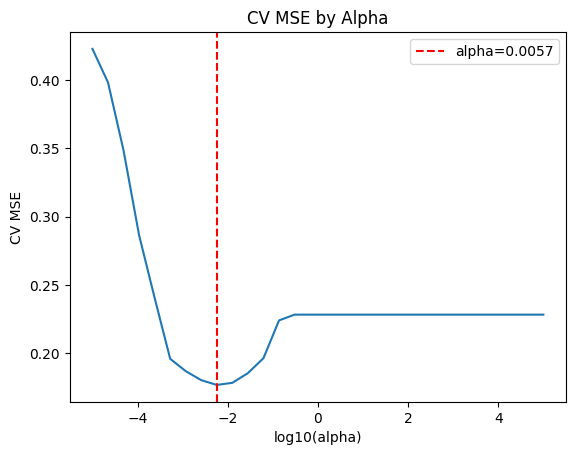

In [52]:
mean_mse_h = np.mean(lasso_h.mse_path_, axis=1)

plt.plot(np.log10(lasso_h.alphas_), mean_mse_h)
plt.axvline(np.log10(lasso_h.alpha_), color='red', linestyle='--', label=f'alpha={lasso_h.alpha_:.4f}')
plt.xlabel('log10(alpha)')
plt.ylabel('CV MSE')
plt.title('CV MSE by Alpha')
plt.legend()
plt.show()

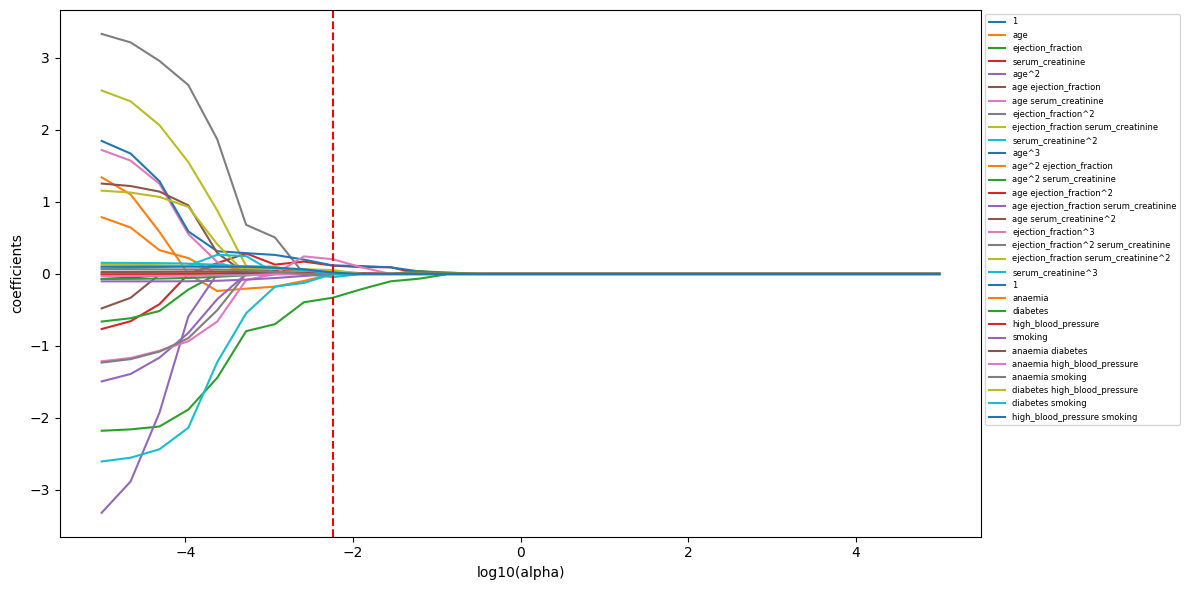

In [53]:
coefs_h = []
for a in alphas_h:
    m = Lasso(alpha=a, max_iter=100000)
    m.fit(X, y_h)
    coefs_h.append(m.coef_)

coefs_h = np.array(coefs_h)

plt.figure(figsize=(12,6))
for i in range(coefs_h.shape[1]):
    plt.plot(np.log10(alphas_h), coefs_h[:,i], label=feature_names_h[i])

plt.axvline(np.log10(lasso_h.alpha_), color='red', linestyle='--')
plt.xlabel('log10(alpha)')
plt.ylabel('coefficients')
plt.legend(fontsize=6, bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

In [54]:
lasso_coefs_h = pd.DataFrame({'feature': feature_names_h, 'coef': lasso_h.coef_})
selected_h = lasso_coefs_h[lasso_coefs_h['coef'] != 0]
prop_zero_h = (lasso_coefs_h['coef']==0).mean()

print(selected_h)
print('proportion zero:', round(prop_zero_h,2))

comparison_h = pd.DataFrame({'feature': feature_names_h, 'OLS': lr_h.coef_, 'LASSO': lasso_h.coef_})
comparison_h['mag_increased'] = abs(comparison_h['LASSO']) > abs(comparison_h['OLS'])
comparison_h['sign_changed'] = np.sign(comparison_h['OLS']) != np.sign(comparison_h['LASSO'])
print(comparison_h)

                                 feature      coef
2                      ejection_fraction -0.329656
3                       serum_creatinine  0.116875
10                                 age^3  0.117992
16                   ejection_fraction^3  0.204822
17  ejection_fraction^2 serum_creatinine  0.032801
19                    serum_creatinine^3 -0.043266
21                               anaemia  0.014178
22                              diabetes  0.000607
23                   high_blood_pressure  0.013608
28          diabetes high_blood_pressure  0.053968
29                      diabetes smoking  0.003466
30           high_blood_pressure smoking  0.017805
proportion zero: 0.61
                                   feature           OLS     LASSO  \
0                                        1 -1.078743e-13  0.000000   
1                                      age  1.539156e+00 -0.000000   
2                        ejection_fraction -2.192494e+00 -0.329656   
3                         serum_cre

 LASSO zeros out most features and keeps only the ones with a clean signal, so its signs make more clinical sense than OLS. OLS is overfitting with this many features, high variance causes some signs to flip. LASSO trades a bit of bias for much lower variance, giving a more interpretable and realistic model.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?


$$
\frac{1}{n}\sum_{i=1}^n (y_i - b_0 - b_1 x_i)^2 + \alpha b_1^2
$$


$$
b_0 = 0
$$

$$
b_1 = \frac{\frac{1}{n}\sum_{i=1}^n x_i y_i}{\frac{1}{n}\sum_{i=1}^n x_i^2 + \alpha}
$$


As $\alpha$ increases, the denominator becomes larger, so $b_1$ becomes smaller.

This means ridge regression shrinks the slope toward 0, but does not usually make it exactly 0.


$$
\frac{1}{n}\sum_{i=1}^n (y_i - b_0 - b_1 x_i)^2 + \alpha |b_1|
$$

The issue is that $|b_1|$ is not differentiable at $b_1 = 0$.

Because of this, we cannot use standard derivatives at that point. This is also why LASSO can set coefficients exactly equal to 0.

It is optimal to set $b_1 = 0$ when:

$$
\left|\frac{1}{n}\sum_{i=1}^n x_i y_i\right| \le \alpha
$$

This means the relationship between $x$ and $y$ is too weak compared to the penalty.